# 📅 Dates Generator Project - Google Colab

This notebook is designed to run the Dates Generator project on Google Colab using GPU acceleration.

### ⚠️ Instructions:
1. Compress your project folder into a file named `project.zip`.
2. Upload the `project.zip` file to the Colab files section (`/content/`).
3. Enable GPU by going to: `Edit` -> `Notebook settings` -> `Hardware accelerator` -> `T4 GPU`.

## 1️⃣ Extract Project and Install Dependencies

In [1]:
# Extract project files
!unzip -q /content/Assignment2_GenAi.zip



In [2]:
# Install required libraries
!pip install -r /content/Assignment2_GenAi/requirements.txt

## 2️⃣ Model Training
You can train all four models sequentially (GAN, VAE, MLP, Flow).

In [6]:
%cd /content/Assignment2_GenAi

/content/Assignment2_GenAi


In [7]:
!python train_all.py


 Starting Training for: MLP 

2026-05-15 13:44:15.481379: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Seed set to 42
Loaded 146462 samples from data.txt
  train=117169  val=14646  test=14647
Training MLP on 117169 samples …

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-15 13:44:23.070089: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Origina

## 3️⃣ Inference (Generating Dates)
After training is complete, you can generate dates using any of the models.

In [8]:
# Example: Generating dates using the GAN model
!python model/predict.py -i example_input.txt -o predictions_gan.txt --model gan


2026-05-15 14:00:27.424164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loaded 1465 conditions from example_input.txt
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-15 14:00:32.298946: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778853632.300554    7192 gpu_device.cc:2020] Created device /job:localhos

In [9]:
# Example: Generating dates using the MLP model
!python model/predict.py -i example_input.txt -o predictions_mlp.txt --model mlp

2026-05-15 14:00:42.259910: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loaded 1465 conditions from example_input.txt
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-15 14:00:46.874754: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778853646.876317    7296 gpu_device.cc:2020] Created device /job:localhos

In [12]:
!python model/predict.py -i example_input.txt -o predictions_vae.txt --model vae


2026-05-15 14:02:50.259492: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loaded 1465 conditions from example_input.txt
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-15 14:02:54.510568: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778853774.512107    7906 gpu_device.cc:2020] Created device /job:localhos

In [14]:
!python model/predict.py -i example_input.txt -o predictions_flow.txt --model flow


2026-05-15 14:04:47.664835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loaded 1465 conditions from example_input.txt
2026-05-15 14:04:51.869612: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778853891.871102    8495 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Flow weights loaded from model/weights/flow/
Loaded Normalizing Flow
Wrote 1465 predictions → predictions_flow.txt


## 4️⃣ Visualize Loss Curves
View the training progress plots generated in the `plots/` directory.

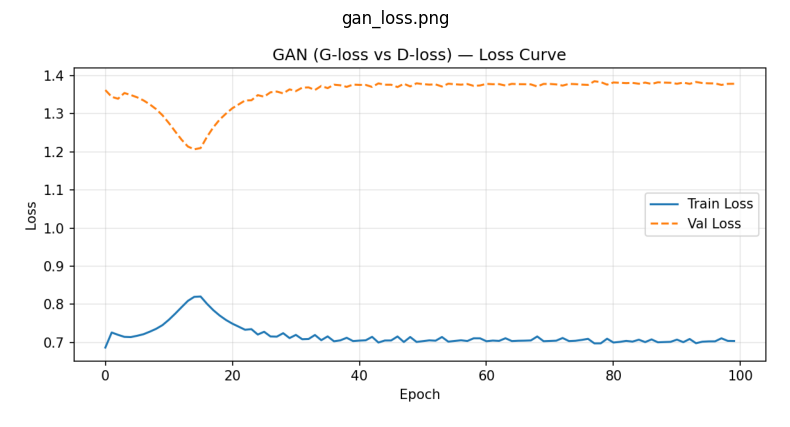

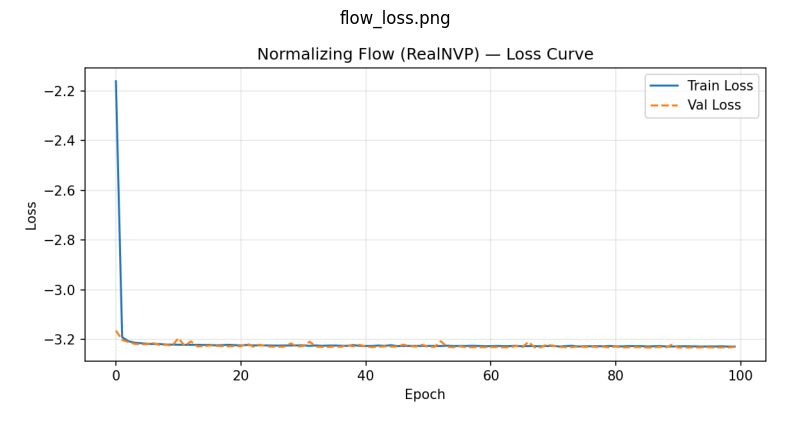

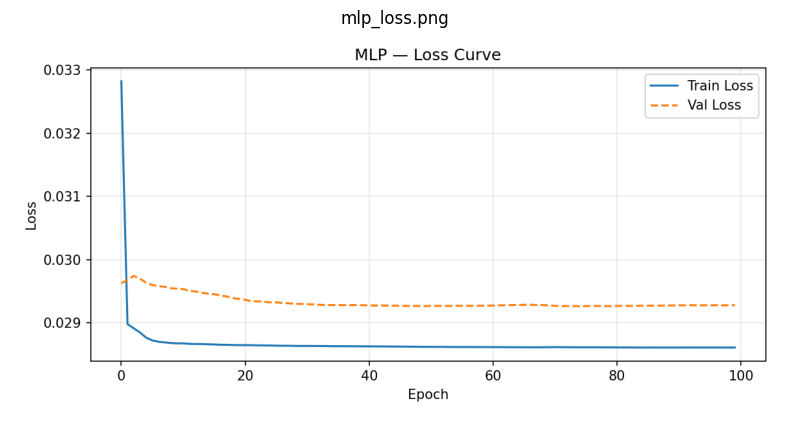

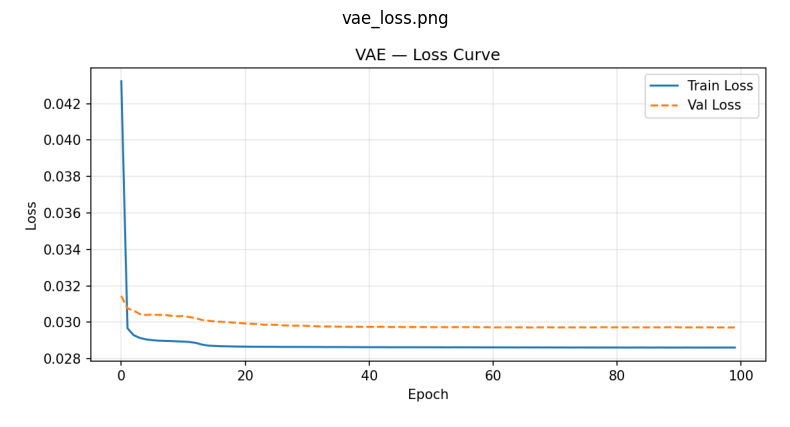

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

plot_dir = 'plots/'
if os.path.exists(plot_dir):
    for img_name in os.listdir(plot_dir):
        if img_name.endswith('.png'):
            img = mpimg.imread(os.path.join(plot_dir, img_name))
            plt.figure(figsize=(10,5))
            plt.imshow(img)
            plt.title(img_name)
            plt.axis('off')
            plt.show()
else:
    print("No plots found. Has the training finished?")